In [1]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot
from scipy.stats import gaussian_kde

/home/iakovos-qpix/Programs/Library/MarleyTest/output/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
file_paths = [
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Fornax_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Fornax_Normal_Hierarchy_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Fornax_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Sukhbold_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Sukhbold_Normal_Hierarchy_1_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Sukhbold_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Nakazato_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Nakazato_Normal_Hierarchy_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Nakazato_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Bollig_No_Oscillations_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Bollig_Normal_Hierarchy_1_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/Bollig_Inverted_Hierarchy_1000_events.root",

]

# Labels for legend
labels = [
    # "No Oscillations - Fornax Model",
    # "Normal Hierarchy - Fornax Model",
    "Inverted Hierarchy - Fornax Model",
    # "No Oscillations - Sukhbold Model",
    # "Normal Hierarchy - Sukhbold Model",
    "Inverted Hierarchy - Sukhbold Model",
    # "No Oscillations - Nakazato Model",
    # "Normal Hierarchy - Nakazato Model",
    "Inverted Hierarchy - Nakazato Model",
    # "No Oscillations - Bollig Model",
    # "Normal Hierarchy - Bollig Model",
    "Inverted Hierarchy - Bollig Model",
]

# Colors for each dataset
colors = plt.cm.tab20.colors

In [3]:
processed_data = {}

for path, label in zip(file_paths, labels):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")

    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    processed_data[label] = clean_s

358000114 photons in Inverted Hierarchy - Fornax Model
223919444 photons in Inverted Hierarchy - Sukhbold Model
281080830 photons in Inverted Hierarchy - Nakazato Model
229913559 photons in Inverted Hierarchy - Bollig Model


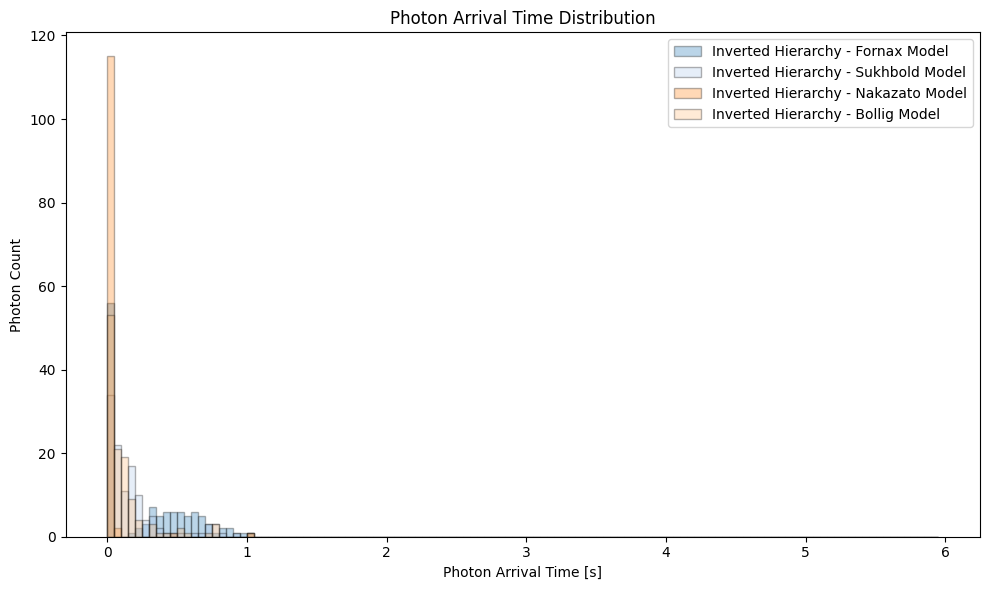

In [13]:
bin_width = 0.05
bins = np.arange(0, 6, bin_width)

plt.figure(figsize=(10, 6))

for label, color in zip(labels, colors):
    data = processed_data[label]

    # Compute histogram (no plotting yet)
    counts, bin_edges = np.histogram(data, bins=bins)

    # Normalize to max = 1
    counts = counts / counts.max()

    # Plot
    plt.hist(
        counts,
        bins=bins,
        color=color,
        alpha=0.3,
        edgecolor="black",   
        linewidth=1.0,       
        label=label
)

plt.xlabel("Photon Arrival Time [s]")
plt.ylabel("Photon Count")
plt.title("Photon Arrival Time Distribution")
#plt.xlim(0, 6)  # Adjust as needed
#plt.ylim(1e5, 2e7)
plt.legend()
plt.tight_layout()
plt.show()